In [ ]:
pip install panda

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### PROJECT NAME

#### EDA on SCMS Delivery history

#### PROBLEM STATEMENT
##### The objective of this project is to analyze shipment and delivery data to understand patterns in freight cost, vendor performance,
##### shipment modes, and delivery efficiency, and identify factors impacting overall logistics cost.

#### GITHUB LINK
#### https://github.com/Shrutishekhar22

#### PROJECT SUMMARY
##### This project involves performing exploratory data analysis (EDA) on shipment data to gain insights into logistics operations.
##### The analysis highlights key trends such as the dominance of air shipments, cost variations across vendors,
##### and the presence of high-cost outliers. It also examines how factors like quantity, shipment mode,
##### and region influence freight cost. The findings help identify opportunities to improve cost efficiency,
##### optimize vendor selection, and enhance overall logistics performance.

In [ ]:
#### DATASET DESCRIPTION
##### ID- Unique identifier for each logistic record
##### Project Code- Code representing the product
##### PQ- Price Quotation reference no.
##### PO/SO- Purchase order and sales order associated with the product
##### ASN/DN- Advanced Shipment Notice or Delivery Note reference
##### Country- Destination Country for the shipment
##### Managed By- Specifies which team manages the project
##### Fullfill via- Method of Fullfillment, such as direct drop shipment
##### Vendor INCO term- Incoterms defining the shipment agreement
##### Shipment Mode- The mode of transpotation used
##### PQ first sent to client date- The date of the price quotation was first sent to client
##### PO first sent to vendor date- The date of the purchase order was first sent to vendor
##### Scheduled Delivery Date- The planned delivery date
##### Brand- The brand name of the product
##### Dosage- The dosage strength of the pharmaceutical product
##### Dosage form- The form in which the product is delivered
##### Unit Measure- The no. of units per pack
##### Line item Quantity- The total no. of units shipped
##### Line item value- The total value of the line item in the shipment
##### Pack Price- Price per pack of the item
##### Unit Price- Price per individual unit of the item
##### Manufacturing site- The location where the item was manufactured
##### First Line designation- Indicates whether the product is designated for the first time use
##### Weight- The weight of the shipment
##### Freight Cost- The cost of shipping the item in U.S dollars
##### Line item insurance- Insurance cost for the line item, if applicable


### DATA WRANGLING

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (9,6)

In [ ]:
#fetching data
df = pd.read_csv('SCMS_Delivery_History_Dataset.csv')
df.head(2)

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.0,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.2,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN


In [ ]:
#Shows rows & columns in the dataset
df.shape

(10324, 33)

In [ ]:
#Shows the name of the column
df.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='str')

In [ ]:
#Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  str    
 2   PQ #                          10324 non-null  str    
 3   PO / SO #                     10324 non-null  str    
 4   ASN/DN #                      10324 non-null  str    
 5   Country                       10324 non-null  str    
 6   Managed By                    10324 non-null  str    
 7   Fulfill Via                   10324 non-null  str    
 8   Vendor INCO Term              10324 non-null  str    
 9   Shipment Mode                 9964 non-null   str    
 10  PQ First Sent to Client Date  10324 non-null  str    
 11  PO Sent to Vendor Date        10324 non-null  str    
 12  Scheduled Delivery Date       10324 non-null  str    
 13  Delivered to

In [ ]:
#Checking sum of null values present in dataset
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [ ]:
#Removes all the duplicate value
df.drop_duplicates(inplace=True)

In [ ]:
#Removes extra spaces before and after column names.
df.columns = df.columns.str.strip()

In [ ]:
#Gives Statistical summary of the dataset
df.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


In [ ]:
#It extract numbers from Dosage, convert to numeric, fill missing values with median, or drop column if empty.
df['Dosage'] = df['Dosage'].astype(str).str.extract(r'(\d+)')
df['Dosage'] = pd.to_numeric(df['Dosage'], errors='coerce')
if df['Dosage'].notnull().sum() > 0:
    df['Dosage'] = df['Dosage'].fillna(df['Dosage'].median())
else:
    df.drop(columns=['Dosage'], inplace=True)

In [ ]:
#checking the remaining null values
df.isnull().sum()

ID                                0
Project Code                      0
PQ #                              0
PO / SO #                         0
ASN/DN #                          0
Country                           0
Managed By                        0
Fulfill Via                       0
Vendor INCO Term                  0
Shipment Mode                   360
PQ First Sent to Client Date      0
PO Sent to Vendor Date            0
Scheduled Delivery Date           0
Delivered to Client Date          0
Delivery Recorded Date            0
Product Group                     0
Sub Classification                0
Vendor                            0
Item Description                  0
Molecule/Test Type                0
Brand                             0
Dosage                            0
Dosage Form                       0
Unit of Measure (Per Pack)        0
Line Item Quantity                0
Line Item Value                   0
Pack Price                        0
Unit Price                  

In [ ]:
#It Convert the column to numbers and replace missing values with 0.
df['Line Item Insurance (USD)'] = pd.to_numeric(df['Line Item Insurance (USD)'], errors='coerce')
df['Line Item Insurance (USD)'] = df['Line Item Insurance (USD)'].fillna(0)

In [ ]:
#Checking the null values
df.isnull().sum()

ID                                0
Project Code                      0
PQ #                              0
PO / SO #                         0
ASN/DN #                          0
Country                           0
Managed By                        0
Fulfill Via                       0
Vendor INCO Term                  0
Shipment Mode                   360
PQ First Sent to Client Date      0
PO Sent to Vendor Date            0
Scheduled Delivery Date           0
Delivered to Client Date          0
Delivery Recorded Date            0
Product Group                     0
Sub Classification                0
Vendor                            0
Item Description                  0
Molecule/Test Type                0
Brand                             0
Dosage                            0
Dosage Form                       0
Unit of Measure (Per Pack)        0
Line Item Quantity                0
Line Item Value                   0
Pack Price                        0
Unit Price                  

In [ ]:
#Fills the most frequently occurring value by using mode function.
df['Shipment Mode'] = df['Shipment Mode'].fillna(df['Shipment Mode'].mode()[0])

In [ ]:
#Checking the final output of null values
df.isnull().sum()

ID                              0
Project Code                    0
PQ #                            0
PO / SO #                       0
ASN/DN #                        0
Country                         0
Managed By                      0
Fulfill Via                     0
Vendor INCO Term                0
Shipment Mode                   0
PQ First Sent to Client Date    0
PO Sent to Vendor Date          0
Scheduled Delivery Date         0
Delivered to Client Date        0
Delivery Recorded Date          0
Product Group                   0
Sub Classification              0
Vendor                          0
Item Description                0
Molecule/Test Type              0
Brand                           0
Dosage                          0
Dosage Form                     0
Unit of Measure (Per Pack)      0
Line Item Quantity              0
Line Item Value                 0
Pack Price                      0
Unit Price                      0
Manufacturing Site              0
First Line Des

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  str    
 2   PQ #                          10324 non-null  str    
 3   PO / SO #                     10324 non-null  str    
 4   ASN/DN #                      10324 non-null  str    
 5   Country                       10324 non-null  str    
 6   Managed By                    10324 non-null  str    
 7   Fulfill Via                   10324 non-null  str    
 8   Vendor INCO Term              10324 non-null  str    
 9   Shipment Mode                 10324 non-null  str    
 10  PQ First Sent to Client Date  10324 non-null  str    
 11  PO Sent to Vendor Date        10324 non-null  str    
 12  Scheduled Delivery Date       10324 non-null  str    
 13  Delivered to

In [ ]:
#Convert into date time format
df['PQ First Sent to Client Date'] = pd.to_datetime(df['PQ First Sent to Client Date'], errors='coerce', dayfirst=True)
df['PO Sent to Vendor Date'] = pd.to_datetime(df['PO Sent to Vendor Date'], errors='coerce', dayfirst=True)
df['Scheduled Delivery Date'] = pd.to_datetime(df['Scheduled Delivery Date'], errors='coerce', dayfirst=True)
df['Delivered to Client Date'] = pd.to_datetime(df['Delivered to Client Date'], errors='coerce', dayfirst=True)
df['Delivery Recorded Date'] = pd.to_datetime(df['Delivery Recorded Date'], errors='coerce', dayfirst=True)

C:\Users\dhara\AppData\Local\Temp\ipykernel_23508\4084612029.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['PQ First Sent to Client Date'] = pd.to_datetime(df['PQ First Sent to Client Date'], errors='coerce', dayfirst=True)
C:\Users\dhara\AppData\Local\Temp\ipykernel_23508\4084612029.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['PO Sent to Vendor Date'] = pd.to_datetime(df['PO Sent to Vendor Date'], errors='coerce', dayfirst=True)
C:\Users\dhara\AppData\Local\Temp\ipykernel_23508\4084612029.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Scheduled

In [ ]:
#Convert into date time format
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            10324 non-null  int64         
 1   Project Code                  10324 non-null  str           
 2   PQ #                          10324 non-null  str           
 3   PO / SO #                     10324 non-null  str           
 4   ASN/DN #                      10324 non-null  str           
 5   Country                       10324 non-null  str           
 6   Managed By                    10324 non-null  str           
 7   Fulfill Via                   10324 non-null  str           
 8   Vendor INCO Term              10324 non-null  str           
 9   Shipment Mode                 10324 non-null  str           
 10  PQ First Sent to Client Date  7643 non-null   datetime64[us]
 11  PO Sent to Vendor Date        4592 non-

# UNIVARIATE ANALYSIS

# Shipment Mode Distribution

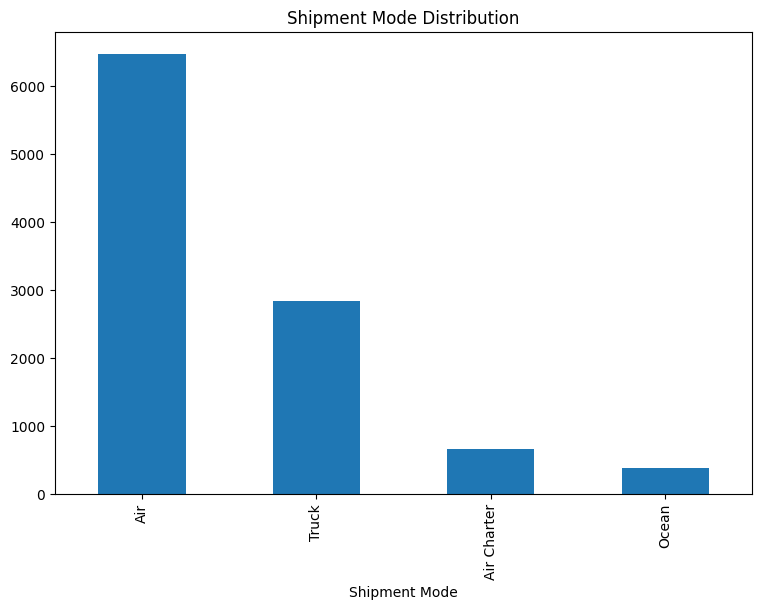

In [ ]:
plt.figure()
df['Shipment Mode'].value_counts().plot(kind='bar')
plt.title("Shipment Mode Distribution")
plt.show()


#### INSIGHTS

##### Bar Plot - A bar chart plots numeric values for levels of a categorical feature as bars.
##### Air shipment appears to be the most frequently used mode compared to other shipment types.

# Top Vendors

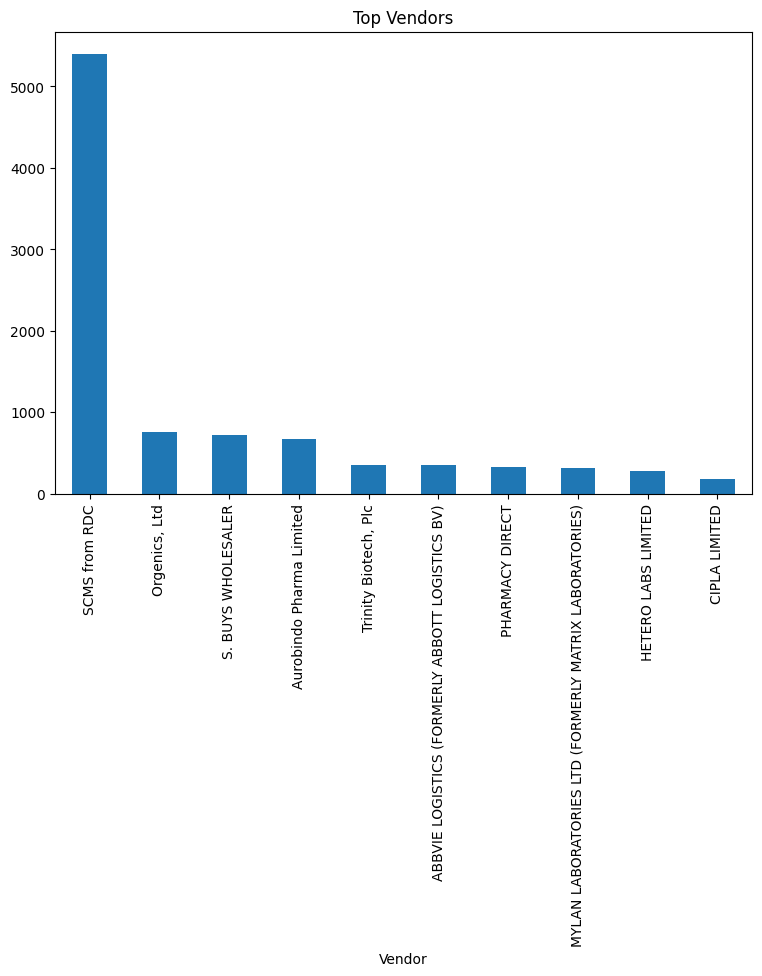

In [ ]:
plt.figure()
df['Vendor'].value_counts().head(10).plot(kind='bar')
plt.title("Top Vendors")
plt.show()

#### INSIGHTS


##### The vendor analysis highlights that the SCMS from RDC is the dominant vendor,
##### followed by a few other key vendors with significantly lower counts.
##### This suggests a high dependency on specific vendors for procurement.

# Quantity Distribution

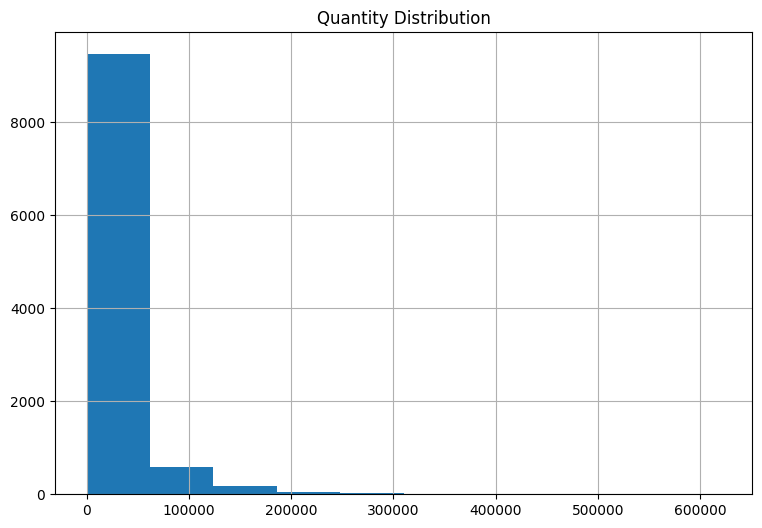

In [ ]:
plt.figure()
df['Line Item Quantity'].hist()
plt.title("Quantity Distribution")
plt.show()

#### INSIGHTS

##### Histogram-A histogram in is a graphical representation of the distribution of numerical data, created by grouping data into continuous ranges
##### line item quantity means how many units of the products were shipped.
##### Most shipments are small, and only a few are large bulk shipments.

# Top Countries

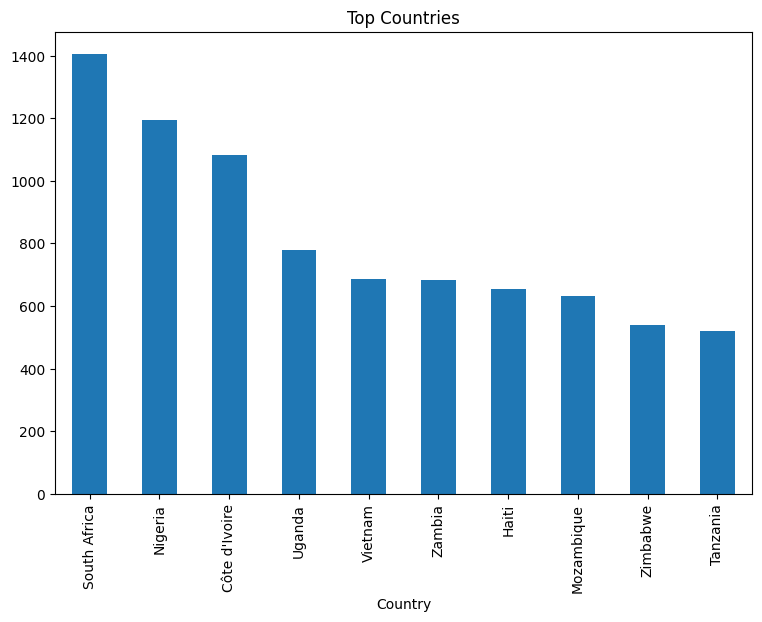

In [ ]:
plt.figure()
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries")
plt.show()

#### INSIGHTS
##### The country distribution chart reveals that South Africa is the dominant destination, contributing the highest number of shipments,
##### followed by other countries with significantly lower volumes.

# Frieght Cost Distribution

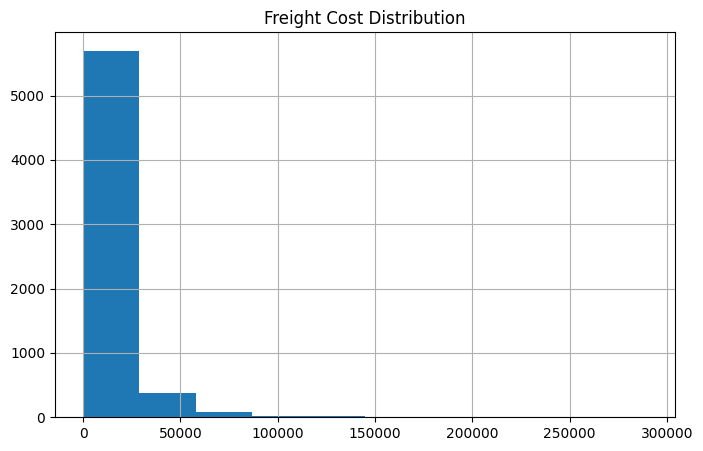

In [ ]:
plt.figure()
df['Freight Cost (USD)'].hist()
plt.title('Freight Cost Distribution')
plt.show()

#### INSIGHTS
##### Freight cost distribution shows how shipping costs are spread, whether most shipments are low-cost or high-cost.
##### The freight cost distribution is heavily right-skewed, where the majority of shipments are concentrated in the lower cost range,
##### while a small number of shipments fall in the very high-cost range.
##### These high-cost shipments act as outliers and are significantly higher than the typical shipment cost.

# BIVARIATE ANALYSIS

# Shipment vs Cost

<Figure size 900x600 with 0 Axes>

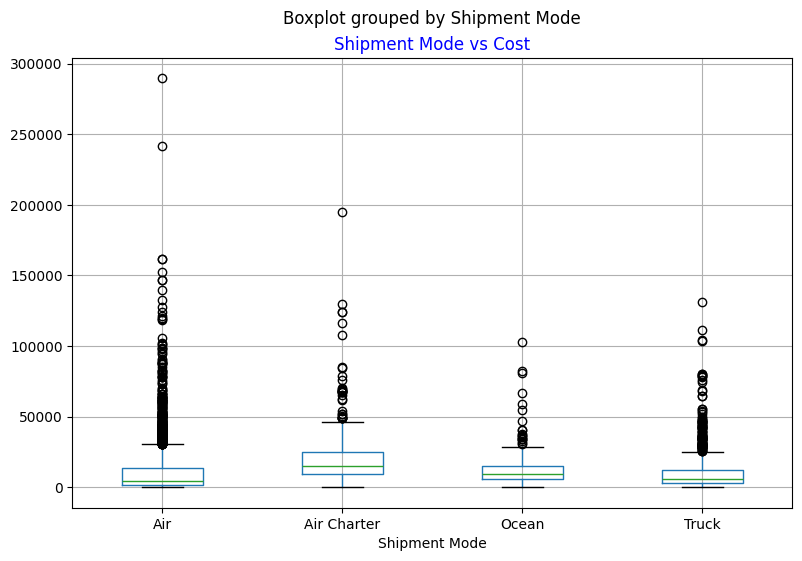

In [ ]:
plt.figure()
df.boxplot(column='Freight Cost (USD)', by='Shipment Mode')
plt.title("Shipment Mode vs Cost", color="Blue")
plt.show()

####INSIGHTS
##### Box plot- Box plot are plotted to visualize the distribution, spread of data and to identify outliers in data
##### The analysis shows that Air shipment dominates the higher cost range.

# Vendor vs Cost

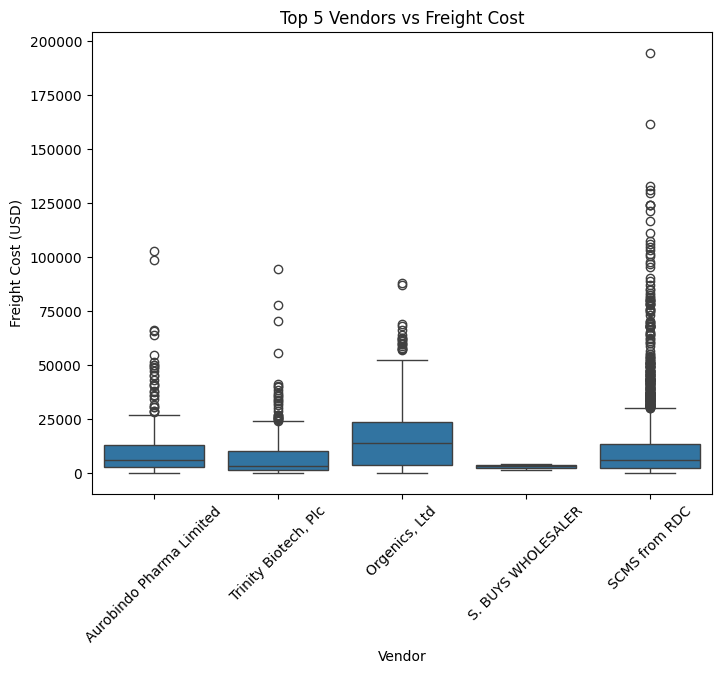

In [ ]:
top_vendors = df['Vendor'].value_counts().head(5).index
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df[df['Vendor'].isin(top_vendors)],
    x='Vendor',
    y='Freight Cost (USD)'
)
plt.xticks(rotation=45)
plt.title("Top 5 Vendors vs Freight Cost")
plt.show()

#### INSIGHTS
##### Orgenics, Ltd has the highest typical shipping cost, while S. BUYS WHOLESALER is the most cost-efficient,
##### and SCMS from RDC shows highly inconsistent and extreme costs.

# Quantity vs Cost

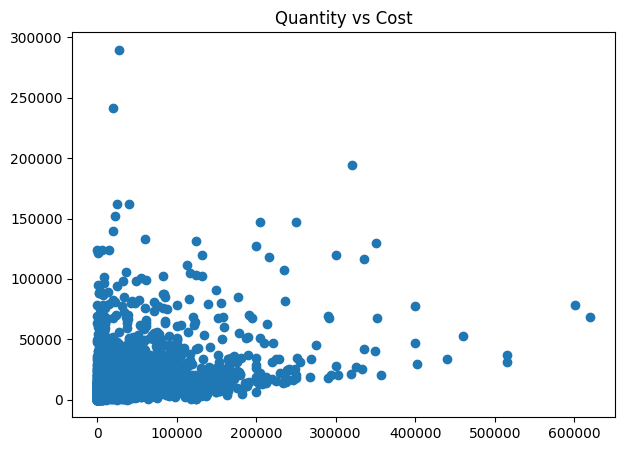

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['Line Item Quantity'], df['Freight Cost (USD)'])
plt.title("Quantity vs Cost")
plt.show()

#### INSIGHTS
##### The scatter plot shows a weak positive relationship between quantity and cost, with most shipments concentrated at
##### low values and significant variability,indicating that multiple factors influence freight cost.

#### INSIGHTS
##### The scatter plot shows a weak positive relationship between quantity and cost, with most shipments concentrated at
##### low values and significant variability,indicating that multiple factors influence freight cost.

# Country vs Shipment Mode

<Figure size 1100x900 with 0 Axes>

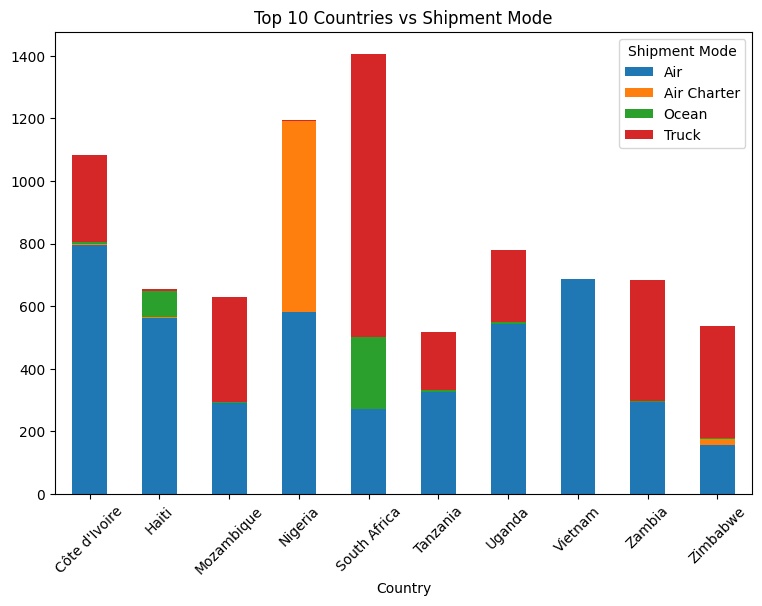

In [ ]:
# Top 10 countries based on frequency
top_countries = df['Country'].value_counts().head(10).index
df_top = df[df['Country'].isin(top_countries)]
plt.figure(figsize=(11, 9))
pd.crosstab(df_top['Country'], df_top['Shipment Mode']).plot(kind='bar', stacked=True)
plt.title("Top 10 Countries vs Shipment Mode")
plt.xticks(rotation=45)
plt.show()

#### INSIGHTS
##### The distribution of shipment modes across countries indicates that certain regions rely more heavily on specific transportation methods.
##### TAir transport dominates across most countries, indicating that shipments are largely time-sensitive and prioritize speed over cost.
##### Truck usage is significantly high in countries like South Africa.

# Delivery Delay

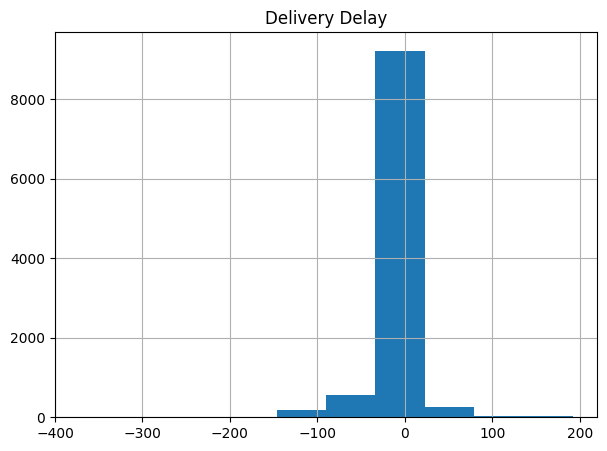

In [ ]:
plt.figure(figsize=(7,5))
if 'Scheduled Delivery Date' in df.columns and 'Delivered to Client Date' in df.columns:
    df['Delay'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days
    df['Delay'].hist()
plt.title("Delivery Delay")
plt.show()


#### INSIGHT
##### Most deliveries are clustered around 0 days delay, indicating that the majority of shipments are delivered on time or with minimal delay.

# MULTIVARIATE ANALYSIS

# Correlation Heatmap

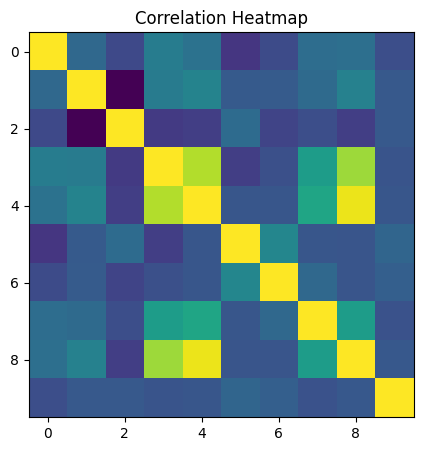

In [ ]:
plt.figure(figsize=(8,5))
plt.imshow(df.select_dtypes(include=np.number).corr())
plt.title("Correlation Heatmap")
plt.show()

#### INSIGHTS
##### Most features show low to moderate correlation (darker shades), indicating that the variables are largely
##### independent and do not strongly influence each other.A few bright spots (strong positive correlations) suggest certain variables
##### are closely related and move together.

# Pair Relationships

<Figure size 800x600 with 0 Axes>

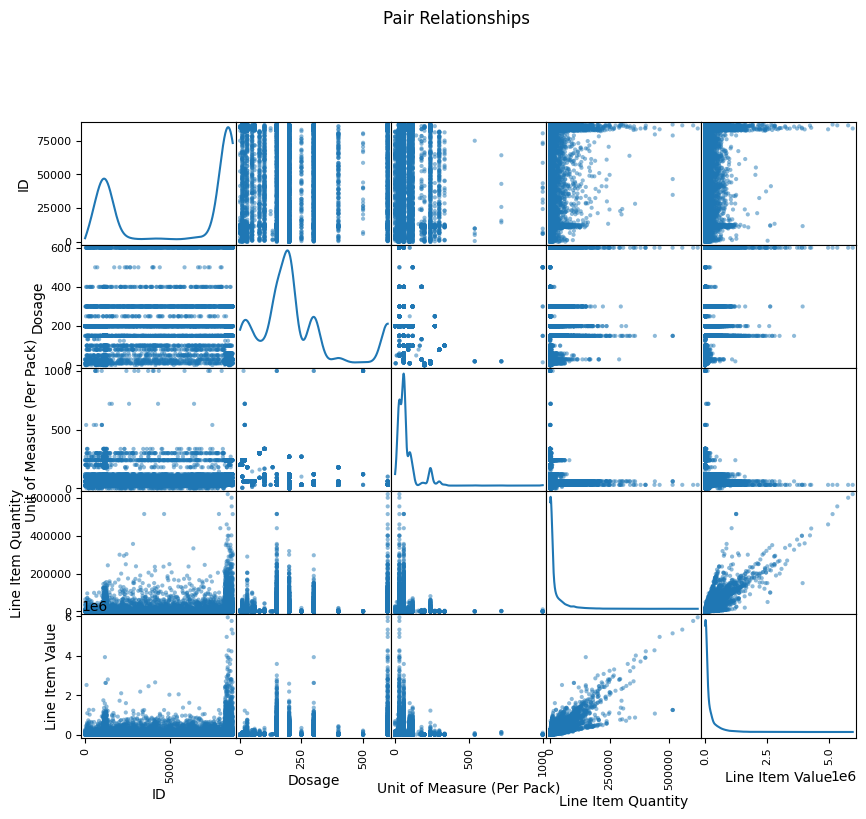

In [ ]:
plt.figure(figsize=(8,6))
cols = df.select_dtypes(include=np.number).columns[:5]  # limit to first 5 columns
pd.plotting.scatter_matrix(
    df[cols],
    figsize=(10,8),
    alpha=0.5,            # reduce overlap
    diagonal='kde'        # smoother distribution on diagonal
)
plt.suptitle("Pair Relationships", y=1.02)
plt.show()

#### INSIGHTS
##### Line Item Quantity and Line Item Value show a strong positive relationship, indicating that higher
##### quantities directly lead to higher total value.Most other variable relationships appear
##### scattered with no clear pattern, suggesting weak or no correlation between features like dosage and unit measures.

# Country + Shipment Mode vs Cost

<Figure size 900x1000 with 0 Axes>

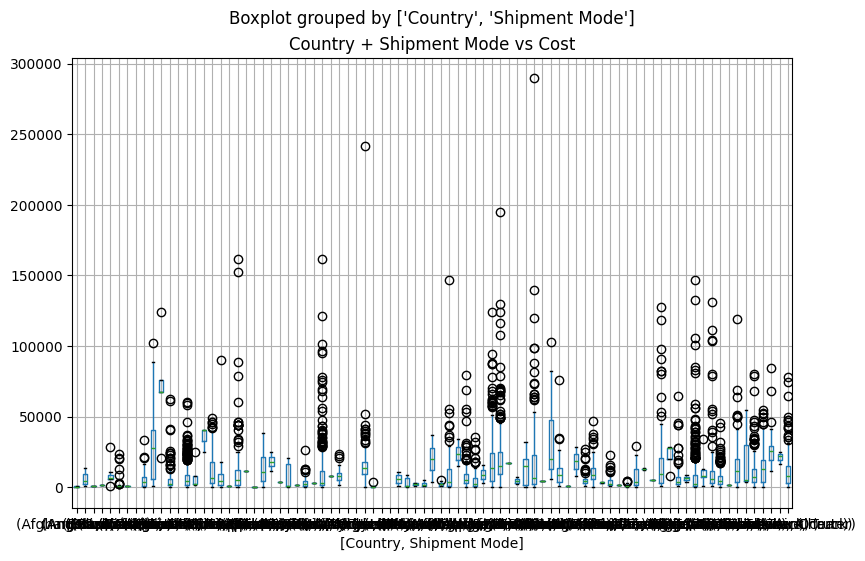

In [ ]:
plt.figure(figsize=(9,10))
df.boxplot(column='Freight Cost (USD)', by=['Country','Shipment Mode'])
plt.title("Country + Shipment Mode vs Cost")
plt.show()

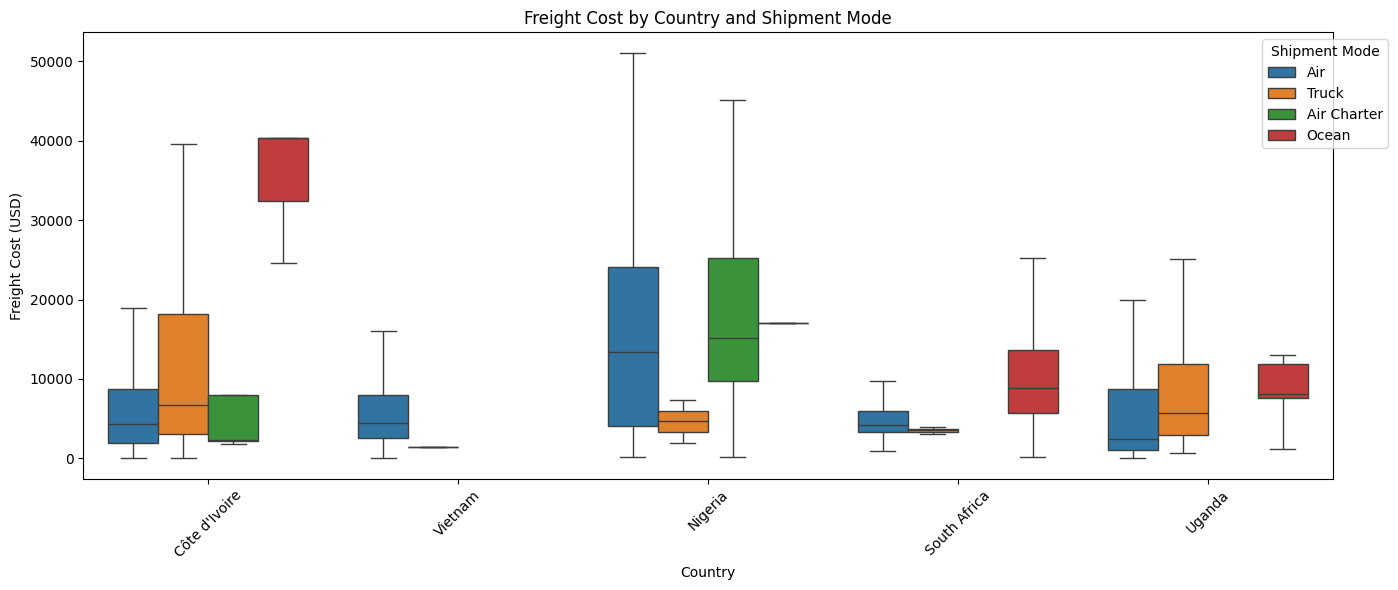

In [ ]:
plt.figure(figsize=(14,6))

# Select top 5 countries to avoid clutter
top_countries = df['Country'].value_counts().head(5).index
filtered_df = df[df['Country'].isin(top_countries)]

sns.boxplot(
    data=filtered_df,
    x='Country',
    y='Freight Cost (USD)',
    hue='Shipment Mode',
    showfliers=False   # removes extreme outliers for clarity
)

plt.xticks(rotation=45)
plt.title("Freight Cost by Country and Shipment Mode")
plt.xlabel("Country")
plt.ylabel("Freight Cost (USD)")
plt.legend(title="Shipment Mode", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

#### INSIGHTS
##### Air Charter and Ocean shipments generally have higher freight costs compared to Air and Truck, indicating they are used
##### for bulk or special high-cost deliveries.Countries like Nigeria and Côte d’Ivoire show
##### high variability in costs across shipment modes, suggesting inconsistent pricing or diverse shipment types.

# Vendor Impact on Quantity vs Cost

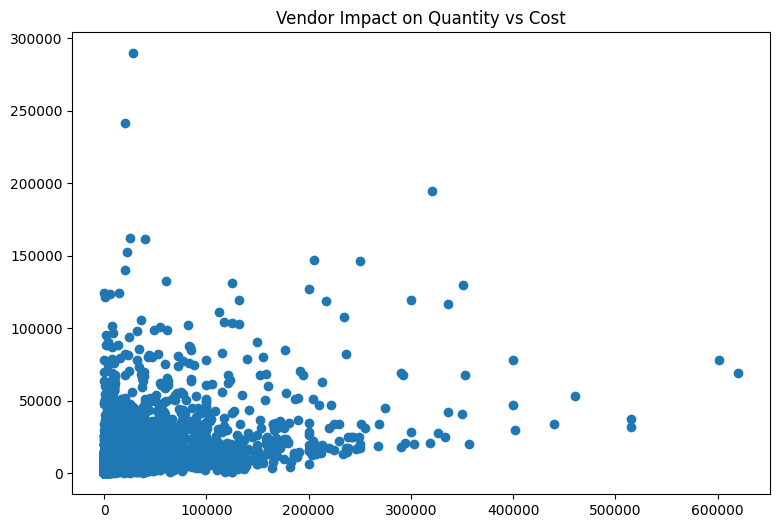

In [ ]:
plt.figure()
plt.scatter(df['Line Item Quantity'], df['Freight Cost (USD)'])
plt.title("Vendor Impact on Quantity vs Cost")
plt.show()

#### INSIGHTS
##### There is a weak positive relationship between quantity and cost, but the points are widely scattered, indicating that cost does
##### not increase consistently with quantity.Presence of several high-cost outliers at lower quantities
##### suggests pricing varies significantly by vendor, likely due to differences in pricing strategy or product type.

## CONCLUSION

##### The analysis shows that air shipment is the most commonly used mode, indicating a preference for faster delivery despite higher costs.
##### A few vendors handle most shipments, with Orgenics, Ltd having higher costs and
##### S. BUYS WHOLESALER being more cost-efficient. Most shipments have low costs, but a few high-cost outliers increase overall expenses.
##### Orders are usually small to medium in size, and cost is influenced by multiple factors, not just quantity.
##### Overall, there is scope to reduce costs by optimizing vendor selection and shipment methods.